Python Data Cleaning and Visualization - <08/09/2026> - <gerbla7878>

Python Data Cleaning and Visualization - 2026-08-09 - gerbla7878
Rows remaining after cleaning: 1205
Cleaned dataframe shape: (1205, 10)
Total Count of Listings: 1205
Minimum Price: 32.0
Maximum Price: 308.0
Mean Price: 132.18008298755186
Median Number of Reviews: 20.0
Mode of Minimum Nights: 1
Standard Deviation of Price: 62.533791011464615
Correlation Between Price and Availability 365: 0.09281345709052662


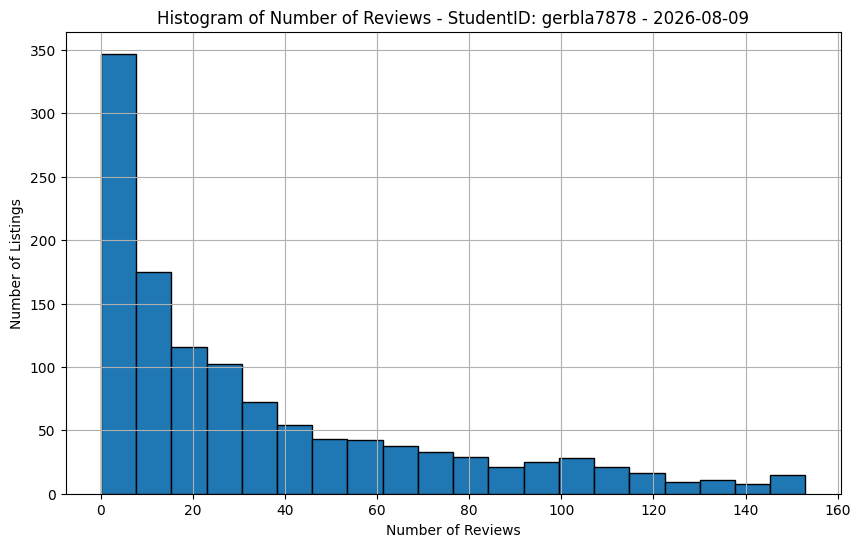

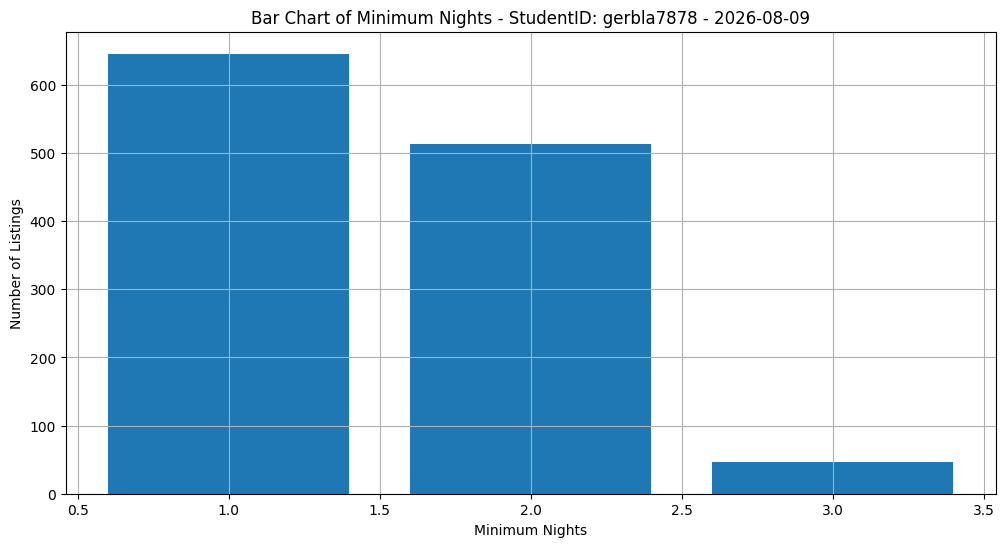

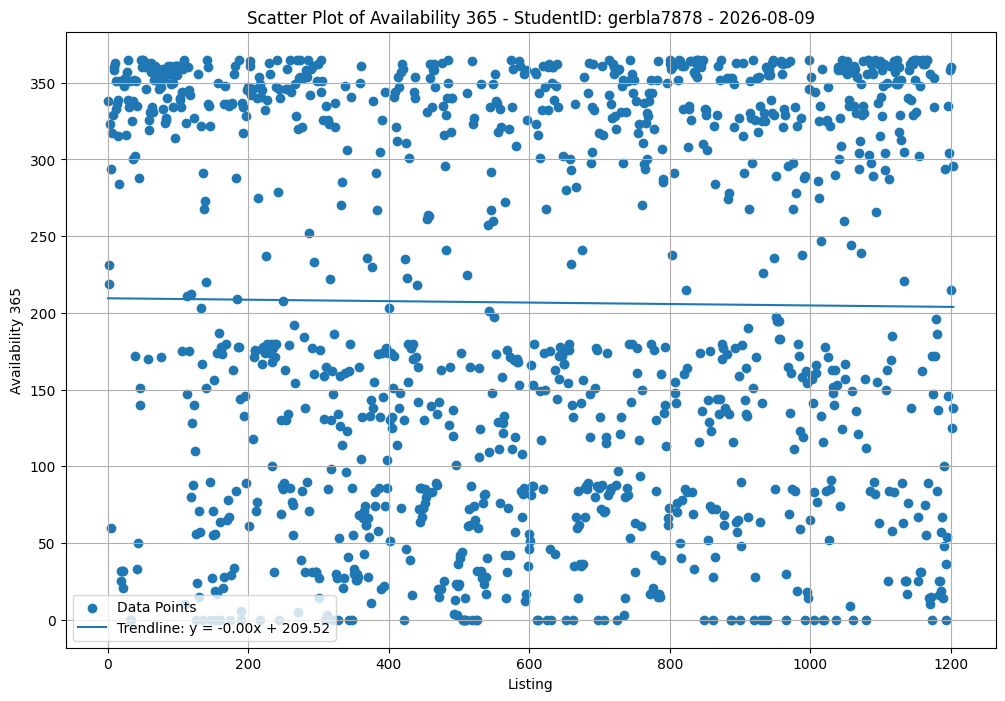

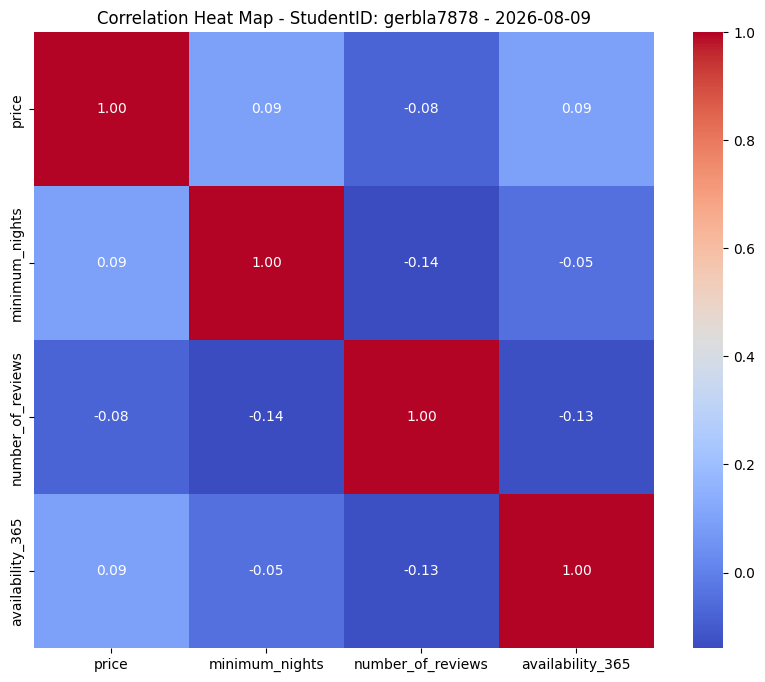

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

todays_date = datetime.now().strftime("%Y-%m-%d")
student_id = "gerbla7878"

print(f"Python Data Cleaning and Visualization - {todays_date} - {student_id}")

file_path = "C:\\Files\\Excel\\DA_PythonR\\AirBnBSummary_v2.xlsx"
df = pd.read_excel(file_path)

df_cleaned = df.copy()

df_cleaned = df_cleaned.drop_duplicates()

df_cleaned = df_cleaned.replace("Private room", "Private Room")

numeric_columns = df_cleaned.select_dtypes(include=np.number).columns

for col in numeric_columns:
    df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].median())

outlier_columns = [
    "price",
    "minimum_nights",
    "number_of_reviews",
    "availability_365"
]

outlier_mask = pd.Series(False, index=df_cleaned.index)

for col in outlier_columns:
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_mask = outlier_mask | (
        (df_cleaned[col] < lower_bound) |
        (df_cleaned[col] > upper_bound)
    )

df_cleaned = df_cleaned.loc[~outlier_mask].copy()

print("Rows remaining after cleaning:", len(df_cleaned))
print("Cleaned dataframe shape:", df_cleaned.shape)

cleaned_file_path = "C:\\Files\\Excel\\DA_PythonR\\AirBnBSummary_v2_Python_Cleaned.xlsx"

df_cleaned.to_excel(cleaned_file_path, index=False)

total_listings = len(df_cleaned)
minimum_price = df_cleaned["price"].min()
maximum_price = df_cleaned["price"].max()
mean_price = df_cleaned["price"].mean()
median_reviews = df_cleaned["number_of_reviews"].median()
mode_minimum_nights = df_cleaned["minimum_nights"].mode().iloc[0]
std_price = df_cleaned["price"].std()

price_availability_corr = df_cleaned["price"].corr(
    df_cleaned["availability_365"]
)

print("Total Count of Listings:", total_listings)
print("Minimum Price:", minimum_price)
print("Maximum Price:", maximum_price)
print("Mean Price:", mean_price)
print("Median Number of Reviews:", median_reviews)
print("Mode of Minimum Nights:", mode_minimum_nights)
print("Standard Deviation of Price:", std_price)
print("Correlation Between Price and Availability 365:", price_availability_corr)

plt.figure(figsize=(10, 6))
plt.hist(df_cleaned["number_of_reviews"], bins=20, edgecolor="black")
plt.xlabel("Number of Reviews")
plt.ylabel("Number of Listings")
plt.title(
    f"Histogram of Number of Reviews - StudentID: {student_id} - {todays_date}"
)
plt.grid(True)
plt.show()

minimum_nights_counts = df_cleaned["minimum_nights"].value_counts().sort_index()

plt.figure(figsize=(12, 6))
plt.bar(minimum_nights_counts.index, minimum_nights_counts.values)
plt.xlabel("Minimum Nights")
plt.ylabel("Number of Listings")
plt.title(
    f"Bar Chart of Minimum Nights - StudentID: {student_id} - {todays_date}"
)
plt.grid(True)
plt.show()

x = np.arange(len(df_cleaned))
y = df_cleaned["availability_365"]

z = np.polyfit(x, y, 1)
p = np.poly1d(z)

plt.figure(figsize=(12, 8))
plt.scatter(x, y, label="Data Points")
plt.plot(
    x,
    p(x),
    label=f"Trendline: y = {z[0]:.2f}x + {z[1]:.2f}"
)
plt.xlabel("Listing")
plt.ylabel("Availability 365")
plt.title(
    f"Scatter Plot of Availability 365 - StudentID: {student_id} - {todays_date}"
)
plt.legend()
plt.grid(True)
plt.show()

heatmap_columns = [
    "price",
    "minimum_nights",
    "number_of_reviews",
    "availability_365"
]

correlation_matrix = df_cleaned[heatmap_columns].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title(
    f"Correlation Heat Map - StudentID: {student_id} - {todays_date}"
)
plt.show()